# Benchmark thuật toán AI Caro 9x9

Notebook này dùng để đo đạc và phân tích hiệu quả thuật toán AI trong file `AI.py`.

Các chỉ số chính:

- `time_ms`: thời gian AI chọn nước đi.
- `nodes`: số trạng thái/node đã xét trong Alpha-Beta.
- `eval_calls`: số lần gọi hàm đánh giá bàn cờ.
- `tt_hits`: số lần dùng lại kết quả từ Transposition Table.
- `alpha_beta_cutoffs`: số lần cắt tỉa Alpha-Beta.
- `trans_table_size`: số trạng thái được lưu trong Transposition Table.
- `eval_cache_size`: số trạng thái được cache điểm đánh giá.

> Lưu ý: Notebook này nên đặt cùng thư mục với `AI.py`. Nếu chạy trên Google Colab/Jupyter, hãy upload `AI.py` vào cùng thư mục với notebook.


## 1. Import thư viện

Ta dùng `time.perf_counter()` để đo thời gian chính xác, `pandas` để tạo bảng kết quả và `matplotlib` để vẽ biểu đồ.

In [1]:
import csv
import math
import statistics
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from AI import AiTicTacToe, N, SCORES, _SIDE_HASH

print(f"Đã import AI.py thành công. Kích thước bàn cờ: {N}x{N}")

Đã import AI.py thành công. Kích thước bàn cờ: 9x9


## 2. Tạo lớp BenchmarkAI

Lớp `BenchmarkAI` kế thừa từ `AiTicTacToe`. Mục tiêu là giữ nguyên logic AI gốc, chỉ thêm các biến đếm để phục vụ benchmark.

Một lần hàm `alpha_beta_transposition()` được gọi sẽ được tính là một node/trạng thái đã xét.

In [2]:
class BenchmarkAI(AiTicTacToe):
    """Kế thừa AI gốc để thêm bộ đếm benchmark mà không cần sửa logic chính."""

    def reset_metrics(self):
        self.nodes = 0
        self.eval_calls = 0
        self.tt_hits = 0
        self.alpha_beta_cutoffs = 0
        self.max_ply_reached = 0

    def evaluate(self):
        self.eval_calls += 1
        return super().evaluate()

    def alpha_beta_transposition(self, depth, bound, alpha, beta, isMaximizing):
        # Mỗi lần đi vào alpha-beta được tính là một trạng thái/node đã xét.
        self.nodes += 1
        self.max_ply_reached = max(self.max_ply_reached, self.depth - depth)

        if self.lastPlayed != 0 and self.isWin(self.currentI, self.currentJ, self.lastPlayed):
            if self.lastPlayed == 1:
                return SCORES["FOUR"] + depth * 200
            return -SCORES["FOUR"] - depth * 200

        if self.emptyCells <= 0:
            return 0

        if depth <= 0 or not bound:
            return self.evaluate()

        alpha_orig, beta_orig = alpha, beta
        key_hash = self._zhash ^ (_SIDE_HASH if isMaximizing else 0)

        tt = self.trans_table.get(key_hash)
        if tt and tt[0] >= depth:
            self.tt_hits += 1
            _, tt_score, tt_flag = tt

            if tt_flag == "EXACT":
                return tt_score

            if tt_flag == "LOWER":
                alpha = max(alpha, tt_score)
            elif tt_flag == "UPPER":
                beta = min(beta, tt_score)

            if alpha >= beta:
                self.alpha_beta_cutoffs += 1
                return tt_score

        best = -math.inf if isMaximizing else math.inf
        state = 1 if isMaximizing else -1

        for i, j in self.orderedMoves(bound, depth):
            saved = (self.currentI, self.currentJ, self.lastPlayed)

            self._place(i, j, state)
            self.currentI, self.currentJ, self.lastPlayed = i, j, state

            new_bound = bound - {(i, j)}
            self.update_bound(i, j, new_bound, radius=1)

            val = self.alpha_beta_transposition(
                depth - 1,
                new_bound,
                alpha,
                beta,
                not isMaximizing
            )

            self._unplace(i, j, state)
            self.currentI, self.currentJ, self.lastPlayed = saved

            if isMaximizing:
                if val > best:
                    best = val

                if val > alpha:
                    alpha = val
                    self.history_table[(i, j)] = self.history_table.get((i, j), 0) + depth * depth

                if alpha >= beta:
                    self.alpha_beta_cutoffs += 1
                    self._remember_killer(depth, (i, j))
                    break
            else:
                if val < best:
                    best = val

                if val < beta:
                    beta = val

                if beta <= alpha:
                    self.alpha_beta_cutoffs += 1
                    self._remember_killer(depth, (i, j))
                    break

        if best <= alpha_orig:
            flag = "UPPER"
        elif best >= beta_orig:
            flag = "LOWER"
        else:
            flag = "EXACT"

        if len(self.trans_table) >= self._TT_MAX:
            self.trans_table.clear()

        self.trans_table[key_hash] = (depth, best, flag)
        return best

## 3. Khai báo các thế cờ dùng để benchmark

Mỗi thế cờ là một danh sách các nước đi dạng:

```python
(row, col, player)
```

Trong đó:

- `player = -1`: người chơi X.
- `player = 1`: AI O.

Các case được chọn để kiểm tra nhiều tình huống khác nhau: bàn cờ rỗng, khai cuộc, trung cuộc, phòng thủ và cơ hội thắng.

In [3]:
TEST_CASES = {
    "empty_board": [],

    # X vừa đi trung tâm, AI cần phản ứng.
    "opening": [
        (4, 4, -1),
    ],

    # Thế cờ trung cuộc, chưa có thắng ngay.
    "middle_game": [
        (4, 4, -1), (4, 5, 1),
        (3, 4, -1), (5, 4, 1),
        (3, 3, -1), (5, 5, 1),
        (2, 4, -1), (6, 4, 1),
    ],

    # Human có chuỗi nguy hiểm, AI cần ưu tiên chặn.
    "defense_threat": [
        (4, 3, -1), (3, 3, 1),
        (4, 4, -1), (3, 4, 1),
        (4, 5, -1),
    ],

    # AI có cơ hội thắng/chốt nhanh.
    "ai_winning_chance": [
        (2, 2, 1), (4, 4, -1),
        (2, 3, 1), (5, 4, -1),
        (2, 4, 1),
    ],
}

print(f"Số thế cờ benchmark: {len(TEST_CASES)}")

Số thế cờ benchmark: 5


## 4. Hàm hỗ trợ benchmark

In [4]:
def apply_moves(ai, moves):
    """
    Áp dụng danh sách nước đi lên bàn cờ AI.

    moves: list[(row, col, player)]
    player: -1 = Human/X, 1 = AI/O
    """
    ai.board = [[0 for _ in range(N)] for _ in range(N)]
    ai.currentI = -1
    ai.currentJ = -1
    ai.lastPlayed = 0
    ai.emptyCells = N * N
    ai.next_bound.clear()

    for row, col, player in moves:
        ai.board[row][col] = player
        ai.currentI, ai.currentJ = row, col
        ai.lastPlayed = player

    ai.sync_state()


def benchmark_one_case(case_name, moves, depth, repeats=3):
    rows = []

    for run_id in range(1, repeats + 1):
        ai = BenchmarkAI(depth=depth)
        apply_moves(ai, moves)
        ai.reset_metrics()

        start = time.perf_counter()
        best_move = ai.best_move_transposition()
        elapsed = time.perf_counter() - start

        rows.append({
            "case": case_name,
            "depth": depth,
            "run": run_id,
            "best_move": best_move,
            "time_ms": elapsed * 1000,
            "nodes": ai.nodes,
            "eval_calls": ai.eval_calls,
            "tt_hits": ai.tt_hits,
            "alpha_beta_cutoffs": ai.alpha_beta_cutoffs,
            "trans_table_size": len(ai.trans_table),
            "eval_cache_size": len(ai.eval_cache),
            "max_ply_reached": ai.max_ply_reached,
        })

    return rows


def run_benchmark(depths=(3, 5, 7), repeats=3):
    all_rows = []

    for case_name, moves in TEST_CASES.items():
        for depth in depths:
            print(f"Đang chạy case={case_name}, depth={depth}...")
            all_rows.extend(benchmark_one_case(case_name, moves, depth, repeats=repeats))

    return pd.DataFrame(all_rows)


def summarize_results(df):
    summary = (
        df.groupby(["case", "depth"], as_index=False)
        .agg(
            best_move_last_run=("best_move", "last"),
            avg_time_ms=("time_ms", "mean"),
            min_time_ms=("time_ms", "min"),
            max_time_ms=("time_ms", "max"),
            avg_nodes=("nodes", "mean"),
            avg_eval_calls=("eval_calls", "mean"),
            avg_tt_hits=("tt_hits", "mean"),
            avg_cutoffs=("alpha_beta_cutoffs", "mean"),
            avg_trans_table_size=("trans_table_size", "mean"),
            avg_eval_cache_size=("eval_cache_size", "mean"),
            max_ply_reached=("max_ply_reached", "max"),
        )
    )
    return summary

## 5. Chạy benchmark

Mặc định notebook chạy `depth = 3, 5, 7`, tương ứng với các mức Easy, Medium, Hard trong game.

Nếu máy yếu hoặc chạy quá lâu, có thể đổi thành:

```python
depths = [3, 5]
repeats = 1
```


In [5]:
depths = [3, 5, 7]
repeats = 3

raw_df = run_benchmark(depths=depths, repeats=repeats)
summary_df = summarize_results(raw_df)

raw_df.to_csv("benchmark_raw.csv", index=False, encoding="utf-8-sig")
summary_df.to_csv("benchmark_summary.csv", index=False, encoding="utf-8-sig")

print("Đã lưu benchmark_raw.csv và benchmark_summary.csv")
summary_df

Đang chạy case=empty_board, depth=3...
Đang chạy case=empty_board, depth=5...
Đang chạy case=empty_board, depth=7...
Đang chạy case=opening, depth=3...
Đang chạy case=opening, depth=5...
Đang chạy case=opening, depth=7...
Đang chạy case=middle_game, depth=3...
Đang chạy case=middle_game, depth=5...
Đang chạy case=middle_game, depth=7...
Đang chạy case=defense_threat, depth=3...
Đang chạy case=defense_threat, depth=5...
Đang chạy case=defense_threat, depth=7...
Đang chạy case=ai_winning_chance, depth=3...
Đang chạy case=ai_winning_chance, depth=5...
Đang chạy case=ai_winning_chance, depth=7...
Đã lưu benchmark_raw.csv và benchmark_summary.csv


,case,depth,best_move_last_run,avg_time_ms,min_time_ms,max_time_ms,avg_nodes,avg_eval_calls,avg_tt_hits,avg_cutoffs,avg_trans_table_size,avg_eval_cache_size,max_ply_reached
0,ai_winning_chance,3,"(2, 1)",0.016867,0.0161,0.0181,0.0,0.0,0.0,0.0,0.0,0.0,0
1,ai_winning_chance,5,"(2, 1)",0.016100,0.0158,0.0164,0.0,0.0,0.0,0.0,0.0,0.0,0
2,ai_winning_chance,7,"(2, 1)",0.015933,0.0158,0.0161,0.0,0.0,0.0,0.0,0.0,0.0,0
3,defense_threat,3,"(4, 2)",0.070767,0.0681,0.0743,0.0,0.0,0.0,0.0,0.0,0.0,0
4,defense_threat,5,"(4, 2)",0.067933,0.0668,0.0689,0.0,0.0,0.0,0.0,0.0,0.0,0
5,defense_threat,7,"(4, 2)",0.065700,0.0642,0.0684,0.0,0.0,0.0,0.0,0.0,0.0,0
6,empty_board,3,"(4, 4)",0.004033,0.0030,0.0056,0.0,0.0,0.0,0.0,0.0,0.0,0
7,empty_board,5,"(4, 4)",0.002867,0.0028,0.0029,0.0,0.0,0.0,0.0,0.0,0.0,0
8,empty_board,7,"(4, 4)",0.002767,0.0027,0.0028,0.0,0.0,0.0,0.0,0.0,0.0,0
9,middle_game,3,"(1, 4)",0.098100,0.0898,0.1032,0.0,0.0,0.0,0.0,0.0,0.0,0


## 6. Xem dữ liệu thô

In [6]:
raw_df.head(20)

,case,depth,run,best_move,time_ms,nodes,eval_calls,tt_hits,alpha_beta_cutoffs,trans_table_size,eval_cache_size,max_ply_reached
0,empty_board,3,1,"(4, 4)",0.0056,0,0,0,0,0,0,0
1,empty_board,3,2,"(4, 4)",0.0035,0,0,0,0,0,0,0
2,empty_board,3,3,"(4, 4)",0.0030,0,0,0,0,0,0,0
3,empty_board,5,1,"(4, 4)",0.0029,0,0,0,0,0,0,0
4,empty_board,5,2,"(4, 4)",0.0029,0,0,0,0,0,0,0
5,empty_board,5,3,"(4, 4)",0.0028,0,0,0,0,0,0,0
6,empty_board,7,1,"(4, 4)",0.0028,0,0,0,0,0,0,0
7,empty_board,7,2,"(4, 4)",0.0028,0,0,0,0,0,0,0
8,empty_board,7,3,"(4, 4)",0.0027,0,0,0,0,0,0,0
9,opening,3,1,"(3, 4)",15.1156,502,398,0,72,96,358,3


## 7. Biểu đồ thời gian chạy theo độ sâu

Biểu đồ này cho thấy khi tăng depth, thời gian chọn nước đi tăng như thế nào.

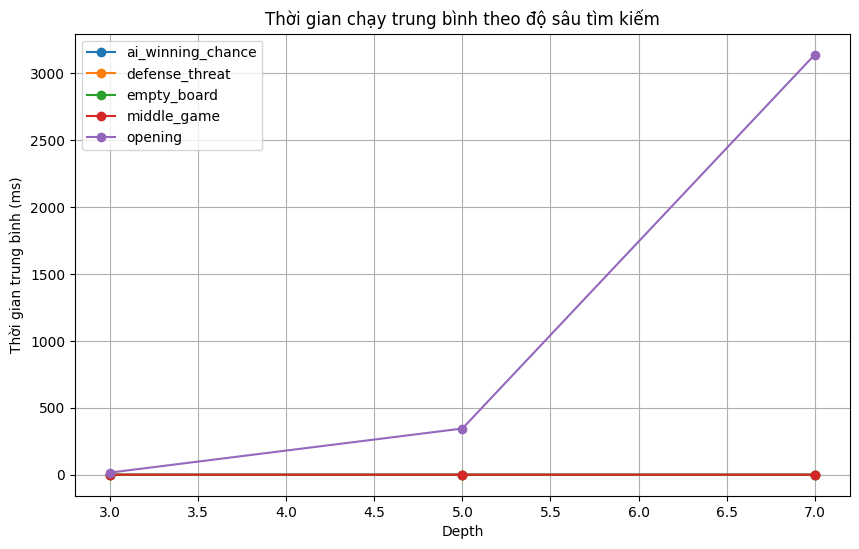

In [7]:
plt.figure(figsize=(10, 6))
for case_name in summary_df["case"].unique():
    data = summary_df[summary_df["case"] == case_name]
    plt.plot(data["depth"], data["avg_time_ms"], marker="o", label=case_name)

plt.xlabel("Depth")
plt.ylabel("Thời gian trung bình (ms)")
plt.title("Thời gian chạy trung bình theo độ sâu tìm kiếm")
plt.legend()
plt.grid(True)
plt.show()

## 8. Biểu đồ số trạng thái đã xét

`avg_nodes` càng lớn nghĩa là thuật toán phải duyệt càng nhiều trạng thái trong cây tìm kiếm.

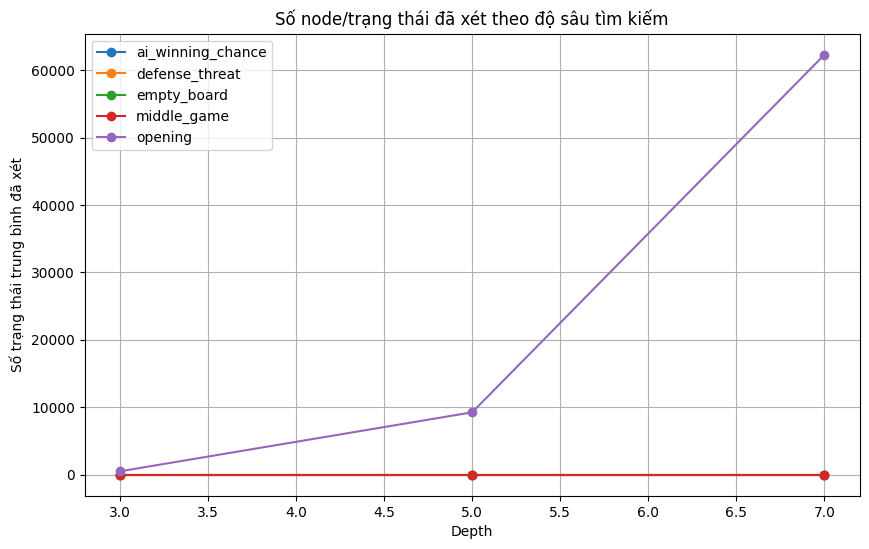

In [8]:
plt.figure(figsize=(10, 6))
for case_name in summary_df["case"].unique():
    data = summary_df[summary_df["case"] == case_name]
    plt.plot(data["depth"], data["avg_nodes"], marker="o", label=case_name)

plt.xlabel("Depth")
plt.ylabel("Số trạng thái trung bình đã xét")
plt.title("Số node/trạng thái đã xét theo độ sâu tìm kiếm")
plt.legend()
plt.grid(True)
plt.show()

## 9. Biểu đồ số lần cắt tỉa Alpha-Beta

Nếu `avg_cutoffs` tăng, tức là thuật toán đã loại bỏ được nhiều nhánh không cần xét tiếp.

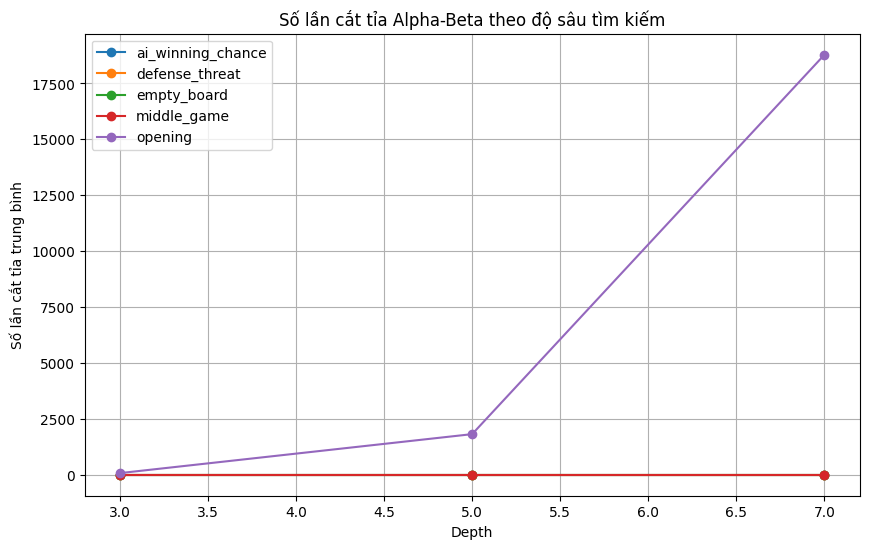

In [9]:
plt.figure(figsize=(10, 6))
for case_name in summary_df["case"].unique():
    data = summary_df[summary_df["case"] == case_name]
    plt.plot(data["depth"], data["avg_cutoffs"], marker="o", label=case_name)

plt.xlabel("Depth")
plt.ylabel("Số lần cắt tỉa trung bình")
plt.title("Số lần cắt tỉa Alpha-Beta theo độ sâu tìm kiếm")
plt.legend()
plt.grid(True)
plt.show()

## 10. Biểu đồ Transposition Table hit

`tt_hits` cho biết số lần thuật toán gặp lại trạng thái đã được tính trước đó và dùng lại kết quả.

Chỉ số này càng cao thì Transposition Table càng có tác dụng giảm tính toán lặp.

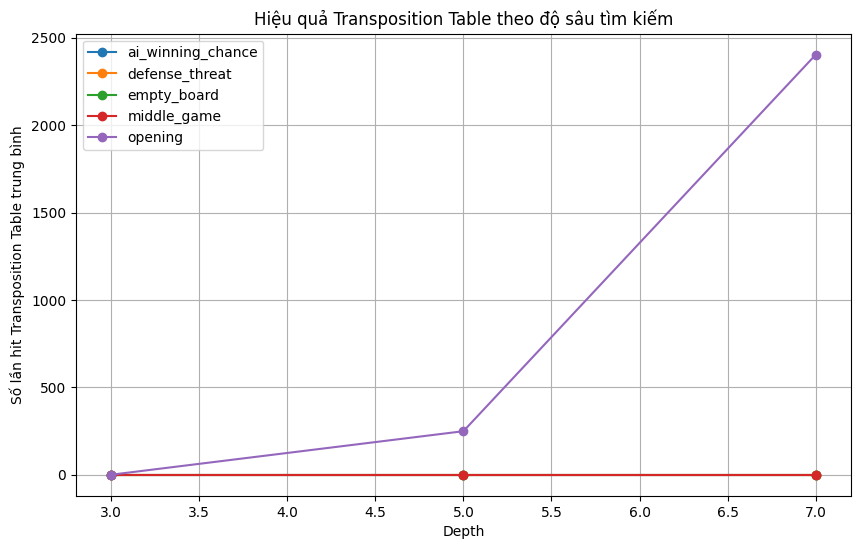

In [10]:
plt.figure(figsize=(10, 6))
for case_name in summary_df["case"].unique():
    data = summary_df[summary_df["case"] == case_name]
    plt.plot(data["depth"], data["avg_tt_hits"], marker="o", label=case_name)

plt.xlabel("Depth")
plt.ylabel("Số lần hit Transposition Table trung bình")
plt.title("Hiệu quả Transposition Table theo độ sâu tìm kiếm")
plt.legend()
plt.grid(True)
plt.show()

## 11. Tính tốc độ xét trạng thái

Chỉ số `nodes_per_second` giúp đánh giá tốc độ duyệt cây tìm kiếm của thuật toán.

In [11]:
summary_df["nodes_per_second"] = summary_df["avg_nodes"] / (summary_df["avg_time_ms"] / 1000)
summary_df[["case", "depth", "avg_time_ms", "avg_nodes", "nodes_per_second"]]

,case,depth,avg_time_ms,avg_nodes,nodes_per_second
0,ai_winning_chance,3,0.016867,0.0,0.000000
1,ai_winning_chance,5,0.016100,0.0,0.000000
2,ai_winning_chance,7,0.015933,0.0,0.000000
3,defense_threat,3,0.070767,0.0,0.000000
4,defense_threat,5,0.067933,0.0,0.000000
5,defense_threat,7,0.065700,0.0,0.000000
6,empty_board,3,0.004033,0.0,0.000000
7,empty_board,5,0.002867,0.0,0.000000
8,empty_board,7,0.002767,0.0,0.000000
9,middle_game,3,0.098100,0.0,0.000000


## 12. Nhận xét tự động từ kết quả

Ô dưới đây tạo đoạn nhận xét dựa trên kết quả benchmark thực tế sau khi chạy.

In [12]:
def generate_report_comment(summary_df):
    min_depth = int(summary_df["depth"].min())
    max_depth = int(summary_df["depth"].max())

    low = summary_df[summary_df["depth"] == min_depth]
    high = summary_df[summary_df["depth"] == max_depth]

    avg_time_low = low["avg_time_ms"].mean()
    avg_time_high = high["avg_time_ms"].mean()
    avg_nodes_low = low["avg_nodes"].mean()
    avg_nodes_high = high["avg_nodes"].mean()
    avg_cutoffs_high = high["avg_cutoffs"].mean()
    avg_tt_high = high["avg_tt_hits"].mean()

    time_ratio = avg_time_high / avg_time_low if avg_time_low > 0 else float("inf")
    node_ratio = avg_nodes_high / avg_nodes_low if avg_nodes_low > 0 else float("inf")

    comment = f"""
Kết quả benchmark cho thấy khi tăng độ sâu tìm kiếm từ depth {min_depth} lên depth {max_depth},
thời gian chạy trung bình tăng từ khoảng {avg_time_low:.2f} ms lên {avg_time_high:.2f} ms,
tức tăng khoảng {time_ratio:.2f} lần. Số trạng thái trung bình đã xét tăng từ {avg_nodes_low:.0f}
lên {avg_nodes_high:.0f}, tức tăng khoảng {node_ratio:.2f} lần.

Điều này phù hợp với đặc trưng của thuật toán Minimax/Alpha-Beta: khi độ sâu tăng, cây tìm kiếm
mở rộng nhanh nên chi phí tính toán tăng. Tuy nhiên, số trạng thái thực tế vẫn được giảm nhờ các kỹ thuật
tối ưu như giới hạn vùng xét nước đi, sắp xếp nước đi, cắt tỉa Alpha-Beta, Transposition Table và Eval Cache.
Ở depth {max_depth}, thuật toán đạt trung bình khoảng {avg_cutoffs_high:.0f} lần cắt tỉa và {avg_tt_high:.0f}
lần dùng lại trạng thái từ Transposition Table.

Như vậy, AI có thể tìm kiếm sâu hơn mà không phải vét cạn toàn bộ không gian trạng thái. Đổi lại, khi chọn
mức Hard với depth lớn, thời gian suy nghĩ của AI sẽ tăng rõ rệt so với Easy và Medium.
"""
    return comment.strip()

print(generate_report_comment(summary_df))

Kết quả benchmark cho thấy khi tăng độ sâu tìm kiếm từ depth 3 lên depth 7,
thời gian chạy trung bình tăng từ khoảng 3.24 ms lên 628.03 ms,
tức tăng khoảng 193.96 lần. Số trạng thái trung bình đã xét tăng từ 100
lên 12455, tức tăng khoảng 124.05 lần.

Điều này phù hợp với đặc trưng của thuật toán Minimax/Alpha-Beta: khi độ sâu tăng, cây tìm kiếm
mở rộng nhanh nên chi phí tính toán tăng. Tuy nhiên, số trạng thái thực tế vẫn được giảm nhờ các kỹ thuật
tối ưu như giới hạn vùng xét nước đi, sắp xếp nước đi, cắt tỉa Alpha-Beta, Transposition Table và Eval Cache.
Ở depth 7, thuật toán đạt trung bình khoảng 3757 lần cắt tỉa và 481
lần dùng lại trạng thái từ Transposition Table.

Như vậy, AI có thể tìm kiếm sâu hơn mà không phải vét cạn toàn bộ không gian trạng thái. Đổi lại, khi chọn
mức Hard với depth lớn, thời gian suy nghĩ của AI sẽ tăng rõ rệt so với Easy và Medium.


## 13. Đoạn viết đưa vào báo cáo

Bạn có thể chỉnh lại các số liệu sau khi chạy benchmark trên máy của mình.

> Benchmark được thực hiện bằng cách chạy AI trên nhiều thế cờ khác nhau gồm bàn cờ rỗng, khai cuộc, trung cuộc, thế cần phòng thủ và thế có cơ hội thắng. Với mỗi thế cờ, chương trình đo thời gian chọn nước đi, số trạng thái đã xét, số lần gọi hàm đánh giá, số lần cắt tỉa Alpha-Beta và số lần sử dụng lại trạng thái từ Transposition Table.
>
> Kết quả cho thấy khi tăng độ sâu tìm kiếm, thời gian chạy và số trạng thái đã xét tăng lên rõ rệt. Đây là đặc điểm tự nhiên của thuật toán tìm kiếm đối kháng vì số nhánh trong cây tìm kiếm tăng nhanh theo độ sâu. Tuy nhiên, nhờ các kỹ thuật tối ưu như chỉ xét các ô lân cận quân cờ đã đánh, sắp xếp nước đi trước khi duyệt, cắt tỉa Alpha-Beta, Transposition Table và Eval Cache, số trạng thái thực tế được xét nhỏ hơn đáng kể so với vét cạn toàn bộ bàn cờ.
>
> Nhìn chung, thuật toán đạt sự cân bằng giữa chất lượng nước đi và thời gian tính toán. Mức Easy có tốc độ phản hồi nhanh nhưng tìm kiếm nông hơn, trong khi mức Hard xét sâu hơn nên đưa ra nước đi tốt hơn nhưng cần nhiều thời gian xử lý hơn.